# Attractor forces for tracking the FEM branch with DER

The `random_1b6_p10` dataset holds Abaqus shell simulations of a clamped ribbon. The left clamp is fixed. Along a homotopy path $f\in[0,1]$ the right clamp is rotated by $f\theta$ about the $x$ axis and translated by $f\,\mathbf d$. Each sample stores the settled shell at $f=0.1,0.2,\dots,1$.

We forward simulate the same load paths with a **DER ribbon** (anisotropic cross-section, same material and clamps) and ask whether it follows **the same branch** as the FEM. The flat ribbon under end compression starts at a bifurcation. Up or down buckling, and the twist sense, are decided by tiny imperfections that DER and the shell do not share, so a free forward simulation often picks another branch.

We then add an **attractor energy** that pulls the rod toward the FEM centerline,
$$E_\text{att}(x)=\tfrac k2\sum_{i\in\text{free nodes}}\lVert p_i-p_i^\text{FEM}(f)\rVert^2,$$
and compare several ways of using it. The goal is to steer the simulation onto the FEM branch while keeping the reported states true DER equilibria ($\nabla E_\text{DER}=0$, stable).

In [1]:
import glob, os, platform, sys, time
from concurrent.futures import ThreadPoolExecutor
from functools import partial

import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dismech_jax import Clipped, Geometry, Linear, Material, MaxTurn, SaddleFree, make_rod

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "../scripts")
from ribbon_data import centerline_and_frame, load, sample_id

DATA = "../data/random_1b6_p10"
THREADS = 16  # samples solved concurrently
T_START = time.time()

## 1. Data

All samples share one mesh. We skip paths that did not complete, and drop samples whose final strain energy is more than 10× the median. In this dataset that removes `56075400`, which never buckles out of plane and instead crumples into short in-plane wrinkles: a shell mode a rod cannot represent.

In [2]:
files = sorted(glob.glob(f"{DATA}/samples/*.npz"))
S_all = [s for s in map(load, files) if s["completed"]]  # skip paths that did not finish
se = np.array([s["ALLSE"][-1] for s in S_all])
keep = se < 10 * np.median(se)
S = [s for s, k in zip(S_all, keep) if k]
ids = [sample_id(s) for s in S]
print(f"{len(files)} samples, {len(files) - len(S_all)} incomplete, "
      f"dropped {[sample_id(s) for s, k in zip(S_all, keep) if not k]}, kept {len(S)}")

s0 = S[0]
L, W, H = s0["l"], s0["w"], s0["thickness"]
E, NU, RHO = s0["young"], s0["poisson"], s0["density"]
print(f"L={L*1e3:.0f} mm  w={W*1e3:.1f} mm  h={H*1e3:.1f} mm  E={E:.0e} Pa  nu={NU}  rho={RHO}  g={s0['gravity']}")
C_fem = np.stack([centerline_and_frame(s)[0] for s in S])  # (S, 10, 61, 3) FEM centerline per frame

146 samples, 1 incomplete, dropped ['56075400'], kept 144
L=100 mm  w=17.3 mm  h=1.0 mm  E=1e+07 Pa  nu=0.5  rho=1000.0  g=[0.   0.   0.01]


## 2. DER ribbon with the FEM settings

The FEM centerline has 61 nodes, so the rod uses $N=61$ nodes on the same reference points ($y=w/2$, the clamp's rotation axis). The cross-section is a $w\times h$ rectangle, with the width along `d1` $=y$:

| term | value | DER slot |
|---|---|---|
| stretch | $EA = Ewh$ | `axs` |
| in-plane (hard) bending, $\kappa_1$ | $EI_1 = Ehw^3/12$ | `ixs1` |
| out-of-plane (easy) bending, $\kappa_2$ | $EI_2 = Ewh^3/12$ | `ixs2` |
| twist | $GJ = \frac{E}{2(1+\nu)}\,\frac{wh^3}{3}$ | `jxs` |

The mass per length is $\rho wh$, under the FEM's tiny gravity $(0,0,0.01)$ m/s². The FEM clamps 10% of the length at each end, which is 6 edges here. All node positions and edge twists in those regions are fixed, and the right clamp follows the same rigid motion as the FEM.

In [3]:
N = 61
DL = L / (N - 1)
nc = int(round(s0["clamp_fraction"] * (N - 1)))  # clamped edges per side
geom = Geometry(length=L, r0=H, axs=W * H, ixs1=H * W**3 / 12, ixs2=W * H**3 / 12, jxs=W * H**3 / 3)
mat = Material(density=RHO, youngs_rod=E, poisson_rod=NU)

rp = s0["rp_x0"]  # rotation axis of the moving clamp (on the centerline)
fixed = np.concatenate([np.arange(4 * nc + 3), np.arange(4 * (N - 1 - nc), 4 * N - 1)])
rod, aux0 = make_rod(geom, mat, N=N, fixed=jnp.asarray(fixed), origin=jnp.array([0.0, rp[1], 0.0]),
                     gravity=jnp.asarray(s0["gravity"]))
q0 = rod.q0
P0 = np.stack([q0[0::4], q0[1::4], q0[2::4]], 1)
print("K = [EA, EA, EI1, EI2, GJ] =", np.asarray(rod.terms[0].model.K))
print(f"{len(rod.idx_x)} free DOFs, clamps: nodes 0..{nc} and {N-1-nc}..{N-1}")

K = [EA, EA, EI1, EI2, GJ] = [1.73031876e+02 1.73031876e+02 4.31714962e-03 1.44193230e-05
 1.92257640e-05]
189 free DOFs, clamps: nodes 0..6 and 54..60


### Boundary path

At load fraction $f$ the right-clamp nodes sit at $R_x(f\theta)(p-r_p)+r_p+f\,\mathbf d$, and their edge twists are $f\theta$. The clamped edges stay along $x$, so the reference director stays $y$ and the twist DOF is exactly $f\theta$. We use 10 substeps per FEM frame (100 load steps).

In [4]:
SUB = 10
fpath = jnp.linspace(0, 1, 10 * SUB + 1)[1:]  # 100 load steps; FEM frame j is step SUB*(j+1)-1
nsteps = len(fpath)
ridx = np.arange(N - 1 - nc, N)

def rotx(a):
    c, s = jnp.cos(a), jnp.sin(a)
    return jnp.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def zs_of(f, theta, d):
    Pr = (P0[ridx] - rp) @ rotx(f * theta).T + rp + f * d
    q = q0.at[4 * ridx].set(Pr[:, 0]).at[4 * ridx + 1].set(Pr[:, 1]).at[4 * ridx + 2].set(Pr[:, 2])
    return q.at[4 * ridx[:-1] + 3].set(f * theta)[rod.idx_z]

## 3. Attractor and solver, all through `rod.solve`

**Attractor as ghost DOFs.** `ribbon, aux_s = rod.with_attractor(aux0, pos)` appends an `Attractor` term
$$E_\text{att}=\tfrac k2\,\lVert q_\text{pos}-q_\text{target}\rVert^2$$
on the free node positions `pos`, not the twists. The targets and $k$ are extra **fixed** DOFs at the end of the state, so the fixed DOFs become `[z, target, k]`, and `zs` sets both at every load step. A moving FEM target, a constant $k$, a seed schedule, and $k=0$ (release) are all just different columns of `zs`.

**Solver options**, the same for every run:
- `direction=Clipped(SaddleFree(), max_step)`. The compressed flat ribbon is a saddle (Hessian eigenvalues down to $-10^6$), and the plain Newton step (`Newton()`) diverges there. The saddle-free step Jacobi-scales the Hessian, $\hat H=D^{-1/2}HD^{-1/2}$, and inverts $|\hat H|$. It always descends, so it converges to **stable** equilibria, as the FEM's dynamic relaxation does. The scaling keeps soft twist modes ($\lambda\sim10^{-4}$) from being swamped by stretch modes ($\lambda\sim10^{7}$). `Clipped` limits each iteration to one edge length of node motion, leaving the twist angles free.
- `predictor=Linear(W_pred)`. Each substep moves the right clamp by about 1 mm, more than half an edge length. Starting from the previous state leaves one edge sheared sideways against the hard axis, a residual of about 4000 N. `W_pred` spreads the clamp's increment linearly over the free span. Its ghost columns are zero.
- `accept=MaxTurn(), passes=10`. DER's reference frames are parallel-transported from the previous step, which is singular at a 180° turn. In a snap-through (e.g. sample `44445815`, whose end is pushed back to the left clamp) one solve can turn an edge that far. `MaxTurn` rejects trial states that turn an edge by more than 60°, and `passes` refreshes the frames and continues, so a snap is followed in increments of at most 60°. (The reference *twist* is recomputed from the current tangents inside `Triplet`, so it is consistent at any step size.)

In [5]:
idx_x = np.asarray(rod.idx_x)
pos = idx_x[idx_x % 4 != 3]  # free node positions
ribbon, aux_s = rod.with_attractor(aux0, pos)
nz = len(ribbon.idx_z)  # [z (rod), target, k]

# Predictor: the increment of the first right-clamp node (x, y, z, edge twist), spread linearly
zpos = {int(d): i for i, d in enumerate(np.asarray(rod.idx_z))}
xref = np.asarray(q0)[idx_x // 4 * 4]
w = np.clip((xref - nc * DL) / (L - 2 * nc * DL), 0, 1)
W_pred = np.zeros((len(idx_x), nz))
W_pred[np.arange(len(idx_x)), [zpos[4 * (N - 1 - nc) + c] for c in idx_x % 4]] = w

max_step = jnp.where(idx_x % 4 == 3, jnp.inf, DL)  # positions: one edge length per iteration; twists: free
OPTS = dict(iters=150, tol=1e-8, direction=Clipped(SaddleFree(), max_step=max_step), predictor=Linear(jnp.asarray(W_pred)),
            accept=MaxTurn(), passes=10)
print(f"{len(pos)} attracted DOFs, fixed DOFs: {len(rod.idx_z)} rod + {len(pos)} targets + 1 stiffness")

141 attracted DOFs, fixed DOFs: 54 rod + 141 targets + 1 stiffness


### Attract, then release in parallel

1. **Attract**: one `ribbon.solve` over the whole path with `zs = [z(f), x_FEM(f), k(f)]`. The target interpolates the FEM centerline linearly between frames, with $f = 0$ the flat ribbon. With `return_aux=True` we also get each step's reference frames.
2. **Release** (*shadow*): every attracted state is released on its own, with a `ribbon.solve` at the same `z` but $k = 0$, starting from that state and its frames. The releases don't depend on each other. Here they run with `lax.map`, so each stops as soon as it converges, but they could equally be `vmap`ped or spread over devices. Each released state is a true DER equilibrium, the one nearest to the attracted path.

We record, at each step, the physical residual $|\nabla E_\text{DER}|$ (with $k=0$), the smallest Hessian eigenvalue $\lambda_\text{min}$ (stability), and how far the release moved the nodes.

An earlier version also tried *re-anchoring*: carrying the released state into the next step. It needs alternating solves inside the scan, and it matched shadow (3.2% median worst-frame error), so it is not repeated here.

In [6]:
def fem_targets(s):
    # FEM centerline at f = 0, 0.1, ..., 1, interpolated to every load step, at the attracted DOFs (100, len(pos))
    C = np.concatenate([P0[None], centerline_and_frame(s)[0]])
    fd = np.concatenate([[0.0], s["f"]])
    q = np.tile(np.asarray(q0), (nsteps, 1))
    for c in range(3):
        q[:, c::4] = np.stack([np.interp(fpath, fd, C[:, i, c]) for i in range(N)], 1)
    return jnp.asarray(q[:, pos])

def physics(xs, zs, auxs):
    # |grad E_DER| and lambda_min with the attractor off (k = 0)
    zs = zs.at[:, -1].set(0.0)
    def one(x, z, a):
        return jnp.linalg.norm(ribbon.residual(x, z, a)), jnp.linalg.eigvalsh(ribbon.hessian(x, z, a)[0])[0]
    return jax.vmap(one)(xs, zs, auxs)

@partial(jax.jit, static_argnames="release")
def run(theta, d, targets, ks, release=False):
    zs = jnp.concatenate([jax.vmap(lambda f: zs_of(f, theta, d))(fpath), targets, ks[:, None]], 1)
    xa, _, auxs = ribbon.solve(zs, aux_s, return_aux=True, **OPTS)           # 1. attract
    xs = xa
    if release:                                                              # 2. release every state
        def free(x, z, a):
            z = z.at[-1].set(0.0)
            xr, _, ar = ribbon.solve(z[None], a, x0=x, z0=z, return_aux=True, **OPTS)
            return xr[0], jax.tree.map(lambda v: v[0], ar)
        xs, auxs = jax.lax.map(lambda a: free(*a), (xa, zs, auxs))  # independent: each stops on its own
    res, lmin = physics(xs, zs, auxs)
    jump = jnp.max(jnp.abs(xs - xa)[:, idx_x % 4 != 3], axis=1)
    return ribbon.join(xs, zs)[:, :rod.n_dofs], res, lmin, jump

XT = [fem_targets(s) for s in S]

def simulate(ks, release=False):
    # Run every sample (threads: each sample's Newton loops stop independently)
    t = time.time()
    with ThreadPoolExecutor(THREADS) as ex:
        out = list(ex.map(lambda i: [np.asarray(a) for a in run(
            S[i]["theta"], jnp.asarray(S[i]["endDisp"]), XT[i], ks, release)], range(len(S))))
    Q, res, lmin, jump = (np.stack(a) for a in zip(*out))
    P = np.stack([Q[..., 0::4], Q[..., 1::4], Q[..., 2::4]], -1)   # (S, 100, 61, 3)
    err = np.sqrt(((P[:, SUB - 1::SUB] - C_fem) ** 2).sum(-1).mean(-1)) / L  # RMS centerline error / L per FEM frame
    return dict(P=P, err=err, res=res, lmin=lmin, jump=jump / L, time=time.time() - t)

## 4. Baseline: forward simulation without an attractor

The error metric is the RMS distance between the DER and FEM centerlines at each FEM frame, divided by $L$. Even on the right branch it is not zero, because a rod and a shell differ, mainly through the shell's anticlastic and stretching effects at large twist. So a small error means the right branch. Errors of 10% or more of $L$ come from following a different branch.

82s, max physical residual 1.0e-08, unstable steps 0
93/144 samples leave the FEM branch somewhere on the path (max error > 10% L); 32 are still off at f = 1


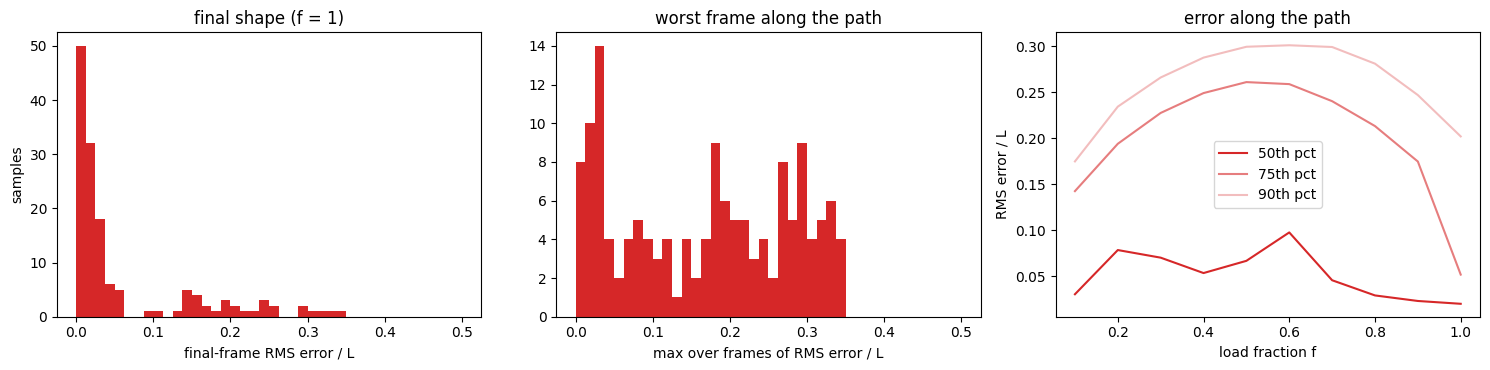

In [7]:
R = {"none": simulate(jnp.zeros(nsteps))}
b = R["none"]
print(f"{b['time']:.0f}s, max physical residual {b['res'].max():.1e}, unstable steps {(b['lmin'] < -1e-6).sum()}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
bins = np.linspace(0, 0.5, 41)
ax[0].hist(np.clip(b["err"][:, -1], 0, 0.5), bins, color="C3")
ax[0].set(xlabel="final-frame RMS error / L", ylabel="samples", title="final shape (f = 1)")
ax[1].hist(np.clip(b["err"].max(1), 0, 0.5), bins, color="C3")
ax[1].set(xlabel="max over frames of RMS error / L", title="worst frame along the path")
f_fem = np.asarray(S[0]["f"])
for qq, a in [(50, 1), (75, .6), (90, .3)]:
    ax[2].plot(f_fem, np.percentile(b["err"], qq, axis=0), "C3", alpha=a, label=f"{qq}th pct")
ax[2].set(xlabel="load fraction f", ylabel="RMS error / L", title="error along the path")
ax[2].legend()
plt.tight_layout()
off = (b["err"].max(1) > 0.1).sum()
print(f"{off}/{len(S)} samples leave the FEM branch somewhere on the path (max error > 10% L); "
      f"{(b['err'][:, -1] > 0.1).sum()} are still off at f = 1")

Many samples **leave the FEM branch during the path** even when the end shapes agree: several paths lead to the same final shape. The 3D comparisons below show the samples with the largest path error. FEM is black, DER without an attractor is red, at $f = 0.1$, $0.5$ and $1$.

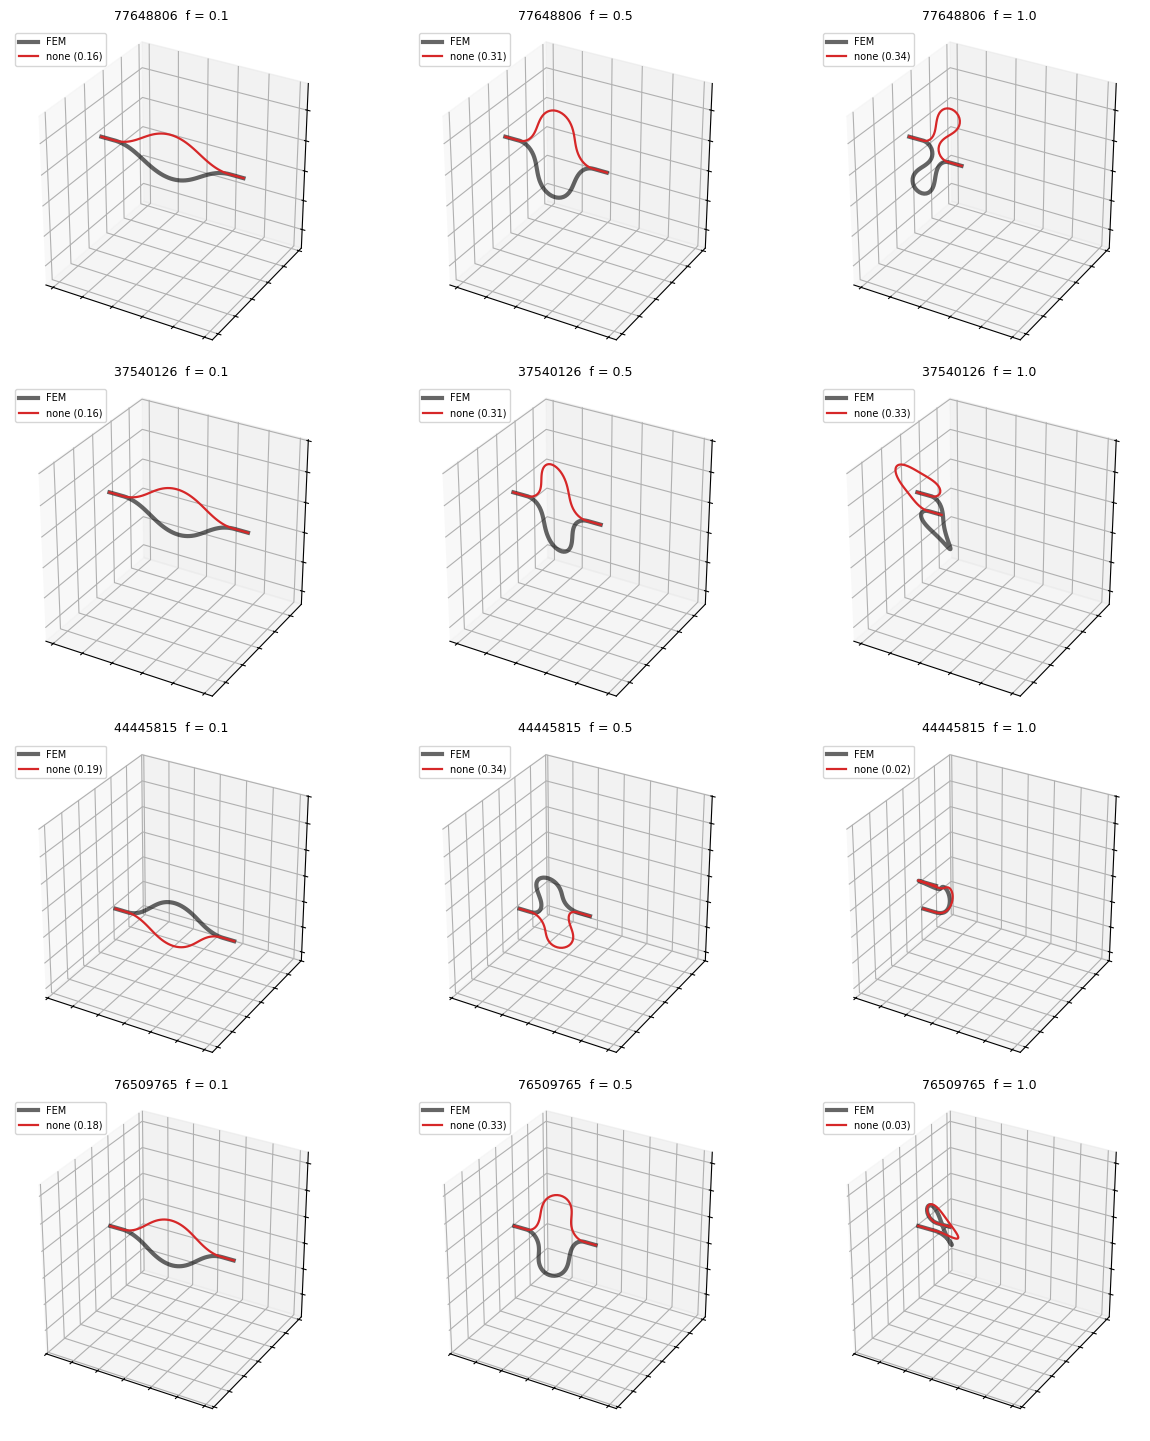

In [8]:
def show(names, samples, frames=(0, 4, 9), colors=("C3", "C0", "C2")):
    fig = plt.figure(figsize=(4.2 * len(frames), 3.6 * len(samples)))
    for r, i in enumerate(samples):
        for c, j in enumerate(frames):
            ax = fig.add_subplot(len(samples), len(frames), r * len(frames) + c + 1, projection="3d")
            ax.plot(*C_fem[i, j].T, "k", lw=3, alpha=.6, label="FEM")
            for n, col in zip(names, colors):
                ax.plot(*R[n]["P"][i, SUB * (j + 1) - 1].T, col, lw=1.6, label=f"{n} ({R[n]['err'][i, j]:.2f})")
            pts = np.concatenate([C_fem[i, :, :, :], P0[None]]).reshape(-1, 3)
            ctr, h = 0.5 * (pts.max(0) + pts.min(0)), 0.55 * np.ptp(pts, 0).max()
            ax.set(xlim=(ctr[0] - h, ctr[0] + h), ylim=(ctr[1] - h, ctr[1] + h), zlim=(ctr[2] - h, ctr[2] + h))
            ax.set_box_aspect((1, 1, 1)); ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
            ax.set_title(f"{ids[i]}  f = {f_fem[j]:.1f}", fontsize=9)
            ax.legend(fontsize=7, loc="upper left")
    plt.tight_layout()

worst = np.argsort(-b["err"].max(1))[:4]
show(["none"], worst)

## 5. Attractor strategies

All variants use the same solver, predictor and load steps.

| variant | schedule | reported state |
|---|---|---|
| **constant** | $k$ at every step | attracted state (biased: $\nabla E_\text{DER}\neq0$) |
| **seed** | $k$ for $f\le 0.1$ (the first FEM frame), then 0 | the forward sim itself |
| **shadow + release** | $k$ at every step, released in parallel afterwards | released state ($\nabla E_\text{DER}=0$) |

$k$ is per node, in N/m. For scale, the softest global bending mode of the free span is a few N/m in total, spread over about 50 nodes. So $k = 0.1$ already rivals the soft modes, and $k = 10$ dominates them.

In [9]:
seed = lambda k: jnp.where(fpath <= 0.1 + 1e-9, k, 0.0)
const = lambda k: jnp.full(nsteps, k)
runs = {
    "const k=0.1": (const(0.1), {}),
    "const k=10": (const(10.0), {}),
    "seed k=0.1": (seed(0.1), {}),
    "seed k=10": (seed(10.0), {}),
    "shadow k=1": (const(1.0), dict(release=True)),
    "shadow k=10": (const(10.0), dict(release=True)),
}
for name, (ks, kw) in runs.items():
    R[name] = simulate(ks, **kw)
    print(f"{name:14s} {R[name]['time']:4.0f}s")

const k=0.1      78s


const k=10       65s


seed k=0.1       71s


seed k=10        71s


shadow k=1      132s


shadow k=10     138s


In [10]:
def row(n):
    r = R[n]
    fe, pe = r["err"][:, -1], r["err"].max(1)
    return (n, np.median(fe), (fe < .05).mean(), np.median(pe), (pe < .1).mean(),
            r["res"].max(), (r["lmin"] < -1e-6).mean(), r["jump"].max())

hdr = ("variant", "final err", "final<5%", "path err", "path<10%", "max |grad E_DER|", "unstable steps", "max release jump/L")
print("{:14s} {:>9s} {:>9s} {:>9s} {:>9s} {:>17s} {:>15s} {:>19s}".format(*hdr))
for n in R:
    print("{:14s} {:9.3f} {:9.0%} {:9.3f} {:9.0%} {:17.1e} {:15.1%} {:19.3f}".format(*row(n)))

variant        final err  final<5%  path err  path<10%  max |grad E_DER|  unstable steps  max release jump/L
none               0.020       74%     0.181       35%           1.0e-08            0.0%               0.000
const k=0.1        0.013       97%     0.022       98%           1.5e-02            1.0%               0.000
const k=10         0.003      100%     0.003      100%           3.7e-01           29.6%               0.000
seed k=0.1         0.017       84%     0.043       67%           7.5e-03            0.0%               0.000
seed k=10          0.018       85%     0.042       68%           1.2e-01            9.2%               0.000
shadow k=1         0.016       95%     0.032       95%           1.0e-08            0.0%               0.388
shadow k=10        0.016       94%     0.032       94%           1.0e-08            0.0%               0.392


*final err* and *path err* are medians over samples: the RMS error at $f=1$, and the worst frame on the path. *final<5%* and *path<10%* are the fractions of samples within those bounds, i.e. on the FEM branch. *max |grad E_DER|* is the largest physical residual of a reported state, which is zero for a true equilibrium. *unstable steps* is the fraction of reported states with a negative Hessian eigenvalue.

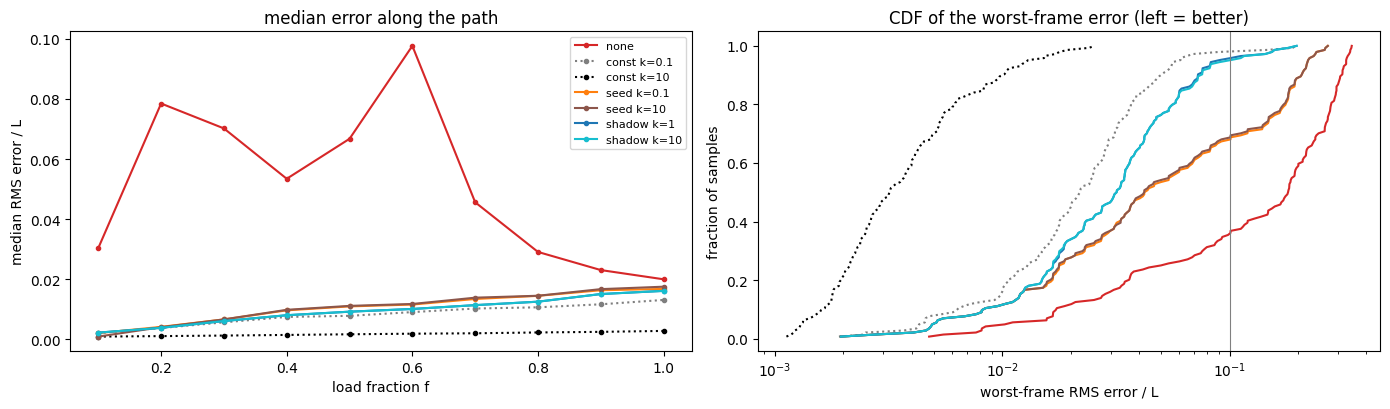

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
styles = {"none": "C3", "const k=0.1": "C7", "const k=10": "k", "seed k=0.1": "C1", "seed k=10": "C5",
          "shadow k=1": "C0", "shadow k=10": "C9"}
for n, col in styles.items():
    ls = ":" if n.startswith("const") else "-"
    ax[0].plot(f_fem, np.median(R[n]["err"], 0), ls, c=col, marker=".", label=n)
    pe = np.sort(R[n]["err"].max(1))
    ax[1].plot(pe, np.arange(1, len(pe) + 1) / len(pe), ls, c=col, label=n)
ax[0].set(xlabel="load fraction f", ylabel="median RMS error / L", title="median error along the path")
ax[1].set(xlabel="worst-frame RMS error / L", ylabel="fraction of samples", xscale="log",
          title="CDF of the worst-frame error (left = better)")
ax[1].axvline(0.1, c="gray", lw=.8)
ax[0].legend(fontsize=8); plt.tight_layout()

The same worst baseline samples, now with the seed and shadow variants. These are the same samples as in section 4.

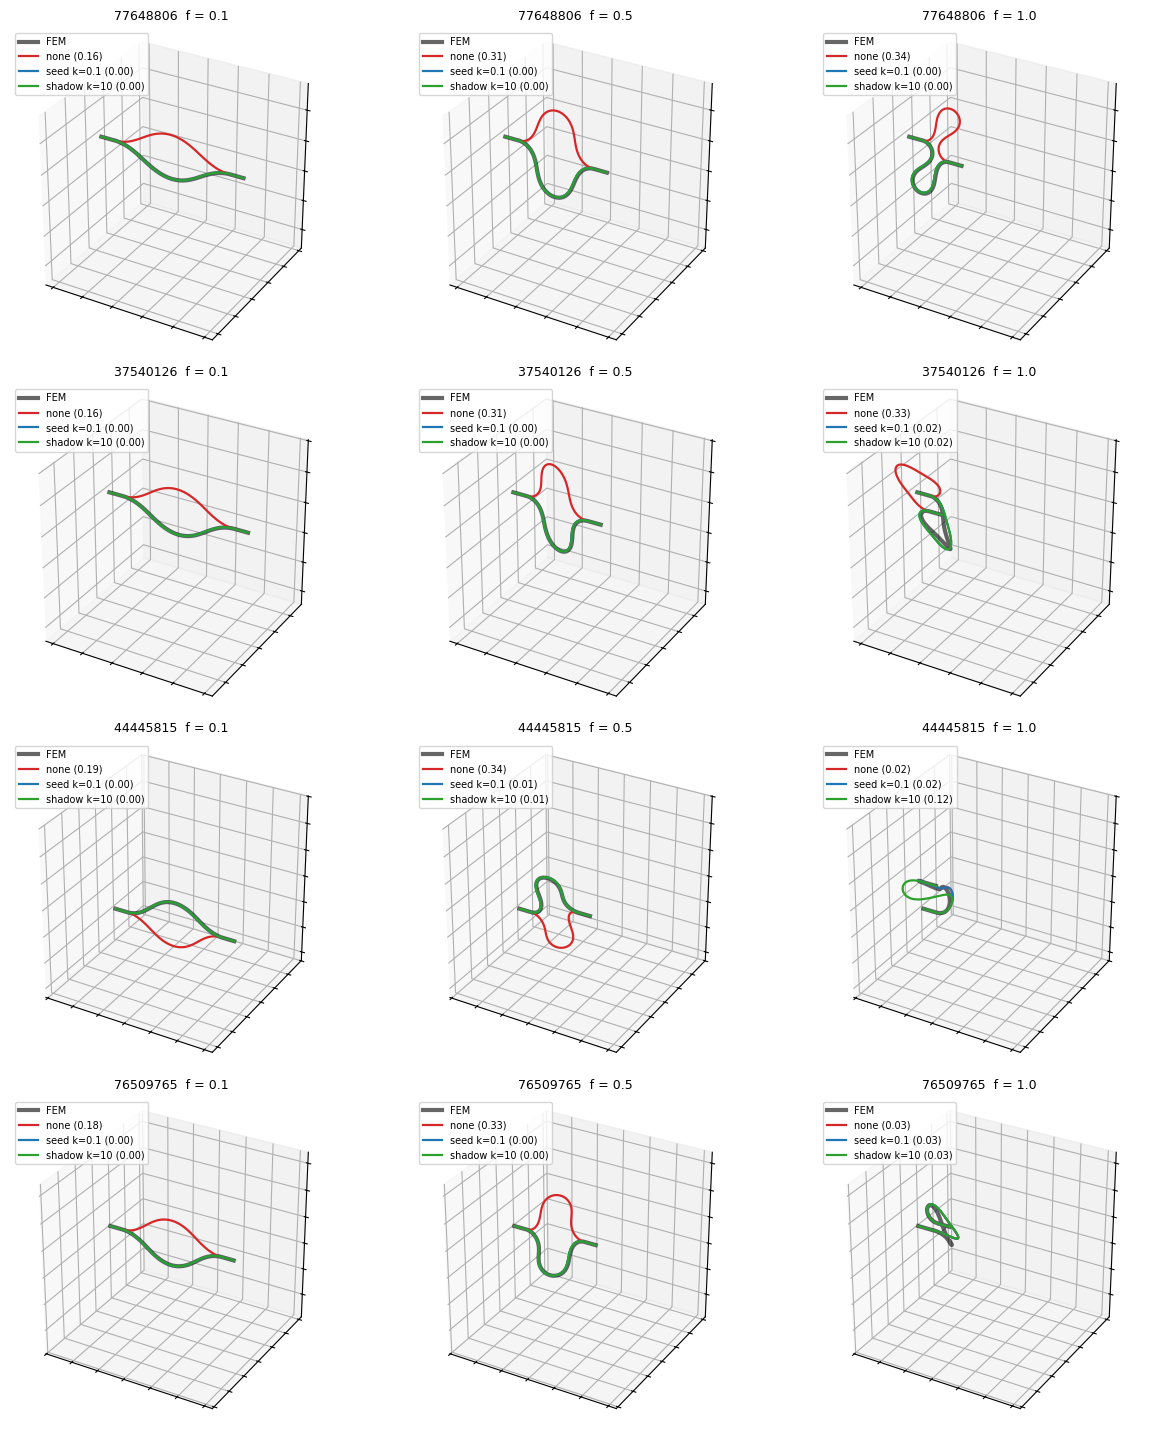

In [12]:
show(["none", "seed k=0.1", "shadow k=10"], worst)

### Where do the release variants still disagree?

When a released state jumps far from the attracted one, the FEM branch is **not a stable DER equilibrium** at that load: no rod state near the FEM shape is stable, a model mismatch. Below is the largest release jump per sample along the path. Samples that jump far are the ones where tracking cannot succeed without a bias.

worst samples after shadow k=10: [('93112435', 0.197), ('40196996', 0.181), ('65269936', 0.158), ('23940889', 0.154), ('58202417', 0.144)]


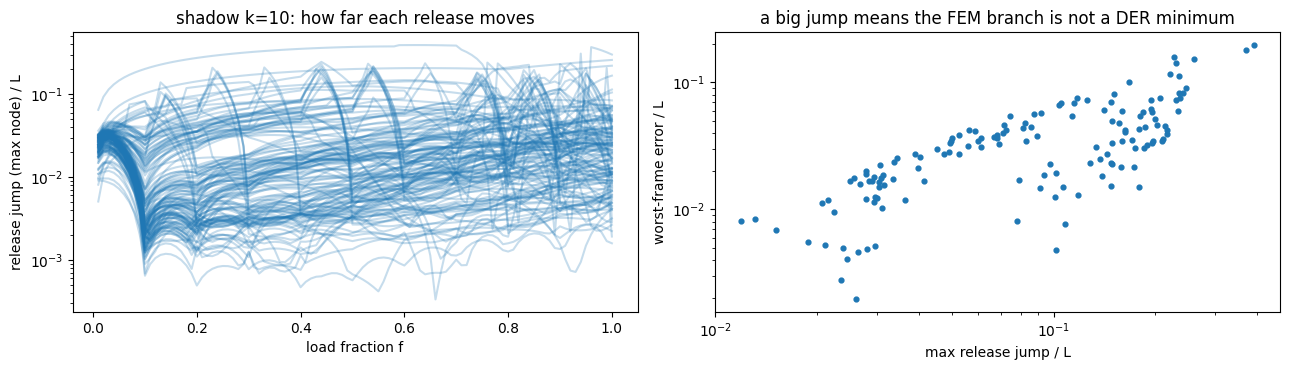

In [13]:
r = R["shadow k=10"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(np.asarray(fpath), r["jump"].T, c="C0", alpha=.25)
ax[0].set(xlabel="load fraction f", ylabel="release jump (max node) / L", yscale="log",
          title="shadow k=10: how far each release moves")
ax[1].scatter(r["jump"].max(1), r["err"].max(1), s=12)
ax[1].set(xscale="log", yscale="log", xlabel="max release jump / L", ylabel="worst-frame error / L",
          title="a big jump means the FEM branch is not a DER minimum")
plt.tight_layout()
bad = np.argsort(-r["err"].max(1))[:5]
print("worst samples after shadow k=10:", [(ids[i], round(float(r["err"].max(1)[i]), 3)) for i in bad])

## 6. Takeaways

The dataset is still growing, so the numbers are approximate. The tables above have the exact values for this run.

- **Without an attractor, DER often takes a different branch from the FEM.** About two thirds of the samples leave the FEM branch somewhere on the path, with a worst-frame error above 10% of $L$. The median worst-frame error is about 18%, even though about three quarters of final shapes still agree within 5%. Most of the time DER buckles the **mirror-image way** at the first step (see the gallery), so the branch is decided at the bifurcation of the compressed flat ribbon.
- **A constant attractor** matches the FEM trivially (98–100% of samples), and more closely as $k$ grows, but the states are not DER equilibria. $|\nabla E_\text{DER}|$ reaches 0.02–0.4 N, and at $k=10$ about 30% of the reported states are unstable without the spring holding them. It is useful only as a guide.
- **Seeding** (attractor only for $f\le0.1$, then a plain forward simulation) fixes most of it: about 70% of samples stay on the branch, with a median worst-frame error of 4%. The seed stiffness barely matters, so the initial bifurcation is the main culprit. (Its nonzero $|\nabla E_\text{DER}|$ comes only from the seeded steps.) The remaining failures are later snap-throughs, where DER and the shell snap at different loads or to different branches.
- **Shadow (attract + release)** is the best physical variant: 95% of samples stay on the branch, with a median worst-frame error of about 3%. Every reported state is a converged ($10^{-8}$ N), stable DER equilibrium. $k$ from 1 to 10 makes no difference.
- **What is left.** The rod-vs-shell model gap is about 1–2% of $L$ on the right branch and grows with $f$. There are also a few samples (e.g. `93112435`, `40196996`) where the release moves far, up to 0.37 L: near the FEM state there is no stable DER equilibrium at that load. An unbiased attractor cannot fix those. They need a better ribbon model (e.g. `dismech_jax.Sano`) or an accepted bias.

**Solver notes.** Everything runs through `rod.solve`. What made it stable on this problem:
1. `SaddleFree` steps, because the plain Newton step diverges at the compressed-ribbon saddle;
2. a `Linear` predictor for the clamp motion;
3. `MaxTurn` with `passes` for snap-throughs;
4. `Triplet` recomputing the reference twist from the current tangents, so large steps stay equilibria after `update`.

Possible next steps:
- also attract the **twist** (match the FEM width director to `m1`), since only positions are pulled now;
- attract only along the **softest Hessian modes**, the ones the bifurcation picks between;
- repeat with the Sano model, to see whether the snap-through failures go away;
- since the target and $k$ are fixed DOFs, gradients with respect to them come for free (implicit function theorem), e.g. to optimise a sparser attractor.

## 7. Timing (CPU)

Wall time of every `simulate` call above. All samples run concurrently in `THREADS` threads, one sample per thread, since each sample's Newton loops stop independently. The first call with each `release` flag includes the JIT compile. *Total* is the whole notebook, including data loading and plots. This is the CPU baseline for a GPU comparison; on a GPU, a `vmap` over samples will likely beat the thread pool.

In [14]:
def cpu_name():
    try:
        import winreg
        key = winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, r"HARDWARE\DESCRIPTION\System\CentralProcessor\0")
        return winreg.QueryValueEx(key, "ProcessorNameString")[0].strip()
    except Exception:
        try:
            return next(l.split(":", 1)[1].strip() for l in open("/proc/cpuinfo") if l.startswith("model name"))
        except Exception:
            return platform.processor() or "unknown"

dev = jax.devices()[0]
print(f"device {dev.platform} ({dev.device_kind}) | {cpu_name()} | {os.cpu_count()} logical cores | {platform.system()} {platform.release()}")
print(f"jax {jax.__version__}, float64 | {len(S)} samples x {nsteps} load steps, {THREADS} threads\n")
print(f"{'variant':14s} {'wall [s]':>9s} {'per sample [s]':>15s}")
for n, r in R.items():
    print(f"{n:14s} {r['time']:9.0f} {r['time'] / len(S):15.2f}")
sim = sum(r["time"] for r in R.values())
print(f"{'all variants':14s} {sim:9.0f}\n{'total notebook':14s} {time.time() - T_START:9.0f}")

device cpu (cpu) | AMD Ryzen 9 9950X 16-Core Processor | 32 logical cores | Windows 11
jax 0.9.0, float64 | 144 samples x 100 load steps, 16 threads

variant         wall [s]  per sample [s]
none                  82            0.57
const k=0.1           78            0.54
const k=10            65            0.45
seed k=0.1            71            0.49
seed k=10             71            0.49
shadow k=1           132            0.92
shadow k=10          138            0.96
all variants         638
total notebook       642
